# Experiment 2: Supervised Training Data Sweep

This notebook studies how the number of supervised initial and boundary data points affects the accuracy of a Physics-Informed Neural Network for Burgers' equation.

The number of collocation points is fixed:

- `N_f = 10000`

The network architecture is fixed:

- 8 hidden layers
- 20 neurons per hidden layer
- `tanh` activation

Only the number of supervised data points changes:

- `N_u = 20`
- `N_u = 40`
- `N_u = 60`
- `N_u = 80`
- `N_u = 100`
- `N_u = 200`

The goal is to test how much supervised initial and boundary data the PINN needs when the physics residual is kept fixed.

In [7]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


# Imports

In [1]:
import os
import time

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import scipy.io

from scipy.stats import qmc
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float64)

# Paths and folders

In [8]:
DATA_PATH = "/content/drive/MyDrive/pinn-burgers-reproduction/data/burgers_shock.mat"

RESULTS_DIR = "/content/drive/MyDrive/pinn-burgers-reproduction/results/experiment_2_training_data"
FIGURES_DIR = f"{RESULTS_DIR}/figures"
TABLES_DIR = f"{RESULTS_DIR}/tables"

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(TABLES_DIR, exist_ok=True)

print("Results will be saved to:", RESULTS_DIR)

Results will be saved to: /content/drive/MyDrive/pinn-burgers-reproduction/results/experiment_2_training_data


# Load the reference solution

In [9]:
data = scipy.io.loadmat(DATA_PATH)

t_grid = data["t"].flatten()[:, None]
x_grid = data["x"].flatten()[:, None]
Exact = data["usol"]

# X and T have shape (number of time points, number of space points)
X, T = np.meshgrid(
    x_grid.flatten(),
    t_grid.flatten()
)

# Full evaluation grid in (t, x) order
X_star = np.hstack(
    (
        T.flatten()[:, None],
        X.flatten()[:, None]
    )
)

# Exact solution flattened in the same order
u_star = Exact.T.flatten()[:, None]

lb = X_star.min(axis=0)
ub = X_star.max(axis=0)

print("t_grid shape:", t_grid.shape)
print("x_grid shape:", x_grid.shape)
print("Exact shape:", Exact.shape)
print("X_star shape:", X_star.shape)
print("u_star shape:", u_star.shape)
print("Lower bounds:", lb)
print("Upper bounds:", ub)

t_grid shape: (100, 1)
x_grid shape: (256, 1)
Exact shape: (256, 100)
X_star shape: (25600, 2)
u_star shape: (25600, 1)
Lower bounds: [ 0. -1.]
Upper bounds: [0.99 1.  ]


# Experiment settings

In [10]:
N_u_values = [20, 40, 60, 80, 100, 200]

# Fixed physics collocation points
N_f_FIXED = 10000

SEED = 1234

ADAM_STEPS = 2000
LBFGS_STEPS = 3000

PRINT_EVERY = 100

# 8 hidden layers, each containing 20 neurons
layers = [2, 20, 20, 20, 20, 20, 20, 20, 20, 1]

print("N_u values:", N_u_values)
print("Fixed N_f:", N_f_FIXED)
print("Network:", layers)
print("Adam steps:", ADAM_STEPS)
print("L-BFGS steps:", LBFGS_STEPS)

N_u values: [20, 40, 60, 80, 100, 200]
Fixed N_f: 10000
Network: [2, 20, 20, 20, 20, 20, 20, 20, 20, 1]
Adam steps: 2000
L-BFGS steps: 3000


## Random seed function

In [11]:
def set_seed(seed):
    """
    Sets NumPy and PyTorch random seeds.
    """

    np.random.seed(seed)
    torch.manual_seed(seed)

# Build all available supervised data

In [12]:
# Initial condition: t = 0
xx_initial = np.hstack(
    (
        X[0:1, :].T,
        T[0:1, :].T
    )
)

u_initial = Exact[:, 0:1]

# Left boundary: x = -1
xx_left = np.hstack(
    (
        X[:, 0:1],
        T[:, 0:1]
    )
)

u_left = Exact[0:1, :].T

# Right boundary: x = 1
xx_right = np.hstack(
    (
        X[:, -1:],
        T[:, -1:]
    )
)

u_right = Exact[-1:, :].T

# Combine all available supervised data
# Reorder columns from (x, t) to (t, x)
X_u_all = np.vstack(
    (
        xx_initial,
        xx_left,
        xx_right
    )
)[:, [1, 0]]

u_all = np.vstack(
    (
        u_initial,
        u_left,
        u_right
    )
)

print("Available supervised inputs:", X_u_all.shape)
print("Available supervised targets:", u_all.shape)

Available supervised inputs: (456, 2)
Available supervised targets: (456, 1)


## Create fixed sampling order and fixed collocation points

In [13]:
set_seed(SEED)

# Fixed ordering of supervised data.
# Smaller N_u cases will be subsets of larger cases.
rng = np.random.default_rng(SEED)

supervised_order = rng.permutation(
    X_u_all.shape[0]
)

# Create exactly one fixed set of collocation points.
# Every N_u experiment will use these same physics points.
sampler = qmc.LatinHypercube(
    d=2,
    seed=SEED
)

sample = sampler.random(
    n=N_f_FIXED
)

X_f_fixed = lb + (ub - lb) * sample

print("Fixed supervised ordering length:", len(supervised_order))
print("Fixed collocation points:", X_f_fixed.shape)

Fixed supervised ordering length: 456
Fixed collocation points: (10000, 2)


# Prepare NumPy data for one N_u

In [14]:
def prepare_training_data(N_u):
    """
    Selects the first N_u supervised points from the fixed ordering.

    The collocation points remain identical for every experiment.
    """

    if N_u <= 0:
        raise ValueError("N_u must be greater than zero.")

    if N_u > X_u_all.shape[0]:
        raise ValueError(
            f"N_u cannot be greater than {X_u_all.shape[0]}."
        )

    selected_indices = supervised_order[:N_u]

    X_u_train = X_u_all[selected_indices, :]
    u_train = u_all[selected_indices, :]

    # Use a copy so no experiment accidentally modifies the shared array
    X_f_train = X_f_fixed.copy()

    return X_u_train, u_train, X_f_train

## Convert NumPy arrays to tensors

In [15]:
def convert_to_tensors(
    X_u_train,
    u_train,
    X_f_train
):
    """
    Converts NumPy arrays into PyTorch tensors.
    """

    tensors = {}

    # Supervised inputs and target values
    tensors["t_u"] = torch.tensor(
        X_u_train[:, 0:1],
        requires_grad=True
    )

    tensors["x_u"] = torch.tensor(
        X_u_train[:, 1:2],
        requires_grad=True
    )

    tensors["u_d"] = torch.tensor(
        u_train
    )

    # Fixed physics collocation points
    tensors["t_f"] = torch.tensor(
        X_f_train[:, 0:1],
        requires_grad=True
    )

    tensors["x_f"] = torch.tensor(
        X_f_train[:, 1:2],
        requires_grad=True
    )

    return tensors

# PINN model

In [16]:
class PINN(nn.Module):
    def __init__(self, layers):
        super().__init__()

        # Buffers move with the model but are not trainable parameters
        self.register_buffer(
            "lb_t",
            torch.tensor(lb)
        )

        self.register_buffer(
            "ub_t",
            torch.tensor(ub)
        )

        self.linears = nn.ModuleList(
            [
                nn.Linear(
                    layers[i],
                    layers[i + 1]
                )
                for i in range(len(layers) - 1)
            ]
        )

        for layer in self.linears:
            nn.init.xavier_normal_(layer.weight)
            nn.init.zeros_(layer.bias)

    def forward(self, t, x):
        inputs = torch.cat(
            (t, x),
            dim=1
        )

        # Normalize inputs to approximately [-1, 1]
        hidden = (
            2.0 * (inputs - self.lb_t)
            / (self.ub_t - self.lb_t)
            - 1.0
        )

        for layer in self.linears[:-1]:
            hidden = torch.tanh(
                layer(hidden)
            )

        output = self.linears[-1](hidden)

        return output

# Burgers equation residual

In [17]:
def net_f(model, t, x):
    """
    Computes the Burgers equation residual:

    f = u_t + u*u_x - (0.01/pi)*u_xx
    """

    u = model(t, x)

    u_t = torch.autograd.grad(
        outputs=u,
        inputs=t,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]

    u_x = torch.autograd.grad(
        outputs=u,
        inputs=x,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]

    u_xx = torch.autograd.grad(
        outputs=u_x,
        inputs=x,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True
    )[0]

    residual = (
        u_t
        + u * u_x
        - (0.01 / np.pi) * u_xx
    )

    return residual

# Evaluation metrics

In [18]:
def relative_l2_error(y_true, y_pred):
    """
    Computes:
    ||y_true - y_pred||_2 / ||y_true||_2
    """

    numerator = np.linalg.norm(
        y_true - y_pred,
        ord=2
    )

    denominator = np.linalg.norm(
        y_true,
        ord=2
    )

    return numerator / denominator


def maximum_absolute_error(y_true, y_pred):
    """
    Maximum pointwise absolute error.
    """

    return np.max(
        np.abs(y_true - y_pred)
    )

# Run one N_u experiment

In [19]:
def run_experiment(N_u):
    print("=" * 70)
    print(f"Running experiment with N_u = {N_u}")
    print("=" * 70)

    set_seed(SEED)

    start_time = time.time()

    # 1. Prepare NumPy arrays
    X_u_train, u_train, X_f_train = prepare_training_data(
        N_u=N_u
    )

    # 2. Convert arrays to tensors
    tensors = convert_to_tensors(
        X_u_train=X_u_train,
        u_train=u_train,
        X_f_train=X_f_train
    )

    # 3. Create a fresh model for this experiment
    model = PINN(layers)

    num_parameters = sum(
        parameter.numel()
        for parameter in model.parameters()
    )

    def loss_fn():
        # Supervised data loss
        u_prediction = model(
            tensors["t_u"],
            tensors["x_u"]
        )

        mse_u = torch.mean(
            (
                tensors["u_d"]
                - u_prediction
            ) ** 2
        )

        # Physics residual loss
        f_prediction = net_f(
            model,
            tensors["t_f"],
            tensors["x_f"]
        )

        mse_f = torch.mean(
            f_prediction ** 2
        )

        total_loss = mse_u + mse_f

        return total_loss, mse_u, mse_f

    # -------------------------------------------------
    # Adam training
    # -------------------------------------------------
    optimizer_adam = torch.optim.Adam(
        model.parameters(),
        lr=1e-3
    )

    for iteration in range(ADAM_STEPS):
        optimizer_adam.zero_grad()

        loss, mse_u, mse_f = loss_fn()

        loss.backward()
        optimizer_adam.step()

        if iteration % PRINT_EVERY == 0:
            print(
                f"Adam {iteration:5d} | "
                f"loss={loss.item():.3e} | "
                f"mse_u={mse_u.item():.3e} | "
                f"mse_f={mse_f.item():.3e}"
            )

    # -------------------------------------------------
    # L-BFGS training
    # -------------------------------------------------
    optimizer_lbfgs = torch.optim.LBFGS(
        model.parameters(),
        lr=1.0,
        max_iter=LBFGS_STEPS,
        max_eval=LBFGS_STEPS + 500,
        history_size=50,
        tolerance_grad=1e-9,
        tolerance_change=1e-12,
        line_search_fn="strong_wolfe"
    )

    lbfgs_counter = [0]

    def closure():
        optimizer_lbfgs.zero_grad()

        loss, mse_u, mse_f = loss_fn()

        loss.backward()

        lbfgs_counter[0] += 1

        if lbfgs_counter[0] % PRINT_EVERY == 0:
            print(
                f"L-BFGS {lbfgs_counter[0]:5d} | "
                f"loss={loss.item():.3e} | "
                f"mse_u={mse_u.item():.3e} | "
                f"mse_f={mse_f.item():.3e}"
            )

        return loss

    optimizer_lbfgs.step(closure)

    # -------------------------------------------------
    # Evaluate on full reference grid
    # -------------------------------------------------
    with torch.no_grad():
        t_test = torch.tensor(
            X_star[:, 0:1]
        )

        x_test = torch.tensor(
            X_star[:, 1:2]
        )

        u_pred = model(
            t_test,
            x_test
        ).numpy()

    relative_error = relative_l2_error(
        u_star,
        u_pred
    )

    max_error = maximum_absolute_error(
        u_star,
        u_pred
    )

    # Calculate final losses
    final_loss, final_mse_u, final_mse_f = loss_fn()

    training_time = time.time() - start_time

    result = {
        "N_u": N_u,
        "N_f": N_f_FIXED,
        "num_parameters": num_parameters,
        "relative_l2_error": relative_error,
        "max_absolute_error": max_error,
        "final_total_loss": final_loss.item(),
        "final_mse_u": final_mse_u.item(),
        "final_mse_f": final_mse_f.item(),
        "training_time_seconds": training_time
    }

    print("Finished experiment:")
    print(result)

    return result

# Run the complete sweep

In [23]:
results = []

results_path = (
    f"{RESULTS_DIR}/training_data_sweep_results.csv"
)

for N_u in N_u_values:
    result = run_experiment(N_u)

    results.append(result)

    # Save after every experiment.
    # This protects completed results if Jupyter crashes later.
    current_results = pd.DataFrame(results)

    current_results.to_csv(
        results_path,
        index=False
    )

    print("Saved current results to:", results_path)

df_results = pd.DataFrame(results)

df_results

Running experiment with N_u = 20
Adam     0 | loss=3.197e-01 | mse_u=2.463e-01 | mse_f=7.341e-02
Adam   100 | loss=1.059e-01 | mse_u=7.833e-02 | mse_f=2.759e-02
Adam   200 | loss=8.004e-02 | mse_u=5.705e-02 | mse_f=2.298e-02
Adam   300 | loss=7.112e-02 | mse_u=4.917e-02 | mse_f=2.196e-02
Adam   400 | loss=6.365e-02 | mse_u=4.356e-02 | mse_f=2.009e-02
Adam   500 | loss=5.848e-02 | mse_u=4.006e-02 | mse_f=1.842e-02
Adam   600 | loss=5.114e-02 | mse_u=3.495e-02 | mse_f=1.620e-02
Adam   700 | loss=3.371e-02 | mse_u=2.251e-02 | mse_f=1.120e-02
Adam   800 | loss=3.042e-02 | mse_u=1.582e-02 | mse_f=1.461e-02
Adam   900 | loss=1.964e-02 | mse_u=1.173e-02 | mse_f=7.913e-03
Adam  1000 | loss=1.421e-02 | mse_u=8.008e-03 | mse_f=6.202e-03
Adam  1100 | loss=1.734e-02 | mse_u=1.104e-02 | mse_f=6.296e-03
Adam  1200 | loss=1.333e-02 | mse_u=7.881e-03 | mse_f=5.445e-03
Adam  1300 | loss=1.149e-02 | mse_u=6.436e-03 | mse_f=5.058e-03
Adam  1400 | loss=9.669e-03 | mse_u=4.939e-03 | mse_f=4.730e-03
Adam  1

KeyboardInterrupt: 

In [24]:
print(df_results)
print("Number of completed runs:", len(df_results))

   N_u    N_f  num_parameters  relative_l2_error  max_absolute_error  \
0   20  10000            3021           0.071326            0.760142   
1   40  10000            3021           0.174923            1.586663   
2   60  10000            3021           0.043906            0.508139   
3   80  10000            3021           0.004870            0.048147   
4  100  10000            3021           0.001657            0.014828   
5  200  10000            3021           0.001175            0.006886   

   final_total_loss   final_mse_u  final_mse_f  training_time_seconds  
0          0.000033  1.881942e-05     0.000015            1173.857579  
1          0.000019  3.408745e-06     0.000015            1168.761920  
2          0.000013  1.528830e-06     0.000012            1122.864284  
3          0.000020  2.197264e-06     0.000018            1169.313155  
4          0.000004  4.372396e-07     0.000004            1167.810348  
5          0.000010  6.985295e-07     0.000009            1165.

## Save final results

In [25]:
results_path = (
    f"{RESULTS_DIR}/training_data_sweep_results.csv"
)

df_results.to_csv(
    results_path,
    index=False
)

print("Final results saved to:", results_path)

Final results saved to: /content/drive/MyDrive/pinn-burgers-reproduction/results/experiment_2_training_data/training_data_sweep_results.csv


# Summary table

In [26]:
summary_columns = [
    "N_u",
    "N_f",
    "num_parameters",
    "relative_l2_error",
    "max_absolute_error",
    "final_total_loss",
    "final_mse_u",
    "final_mse_f",
    "training_time_seconds"
]

df_summary = (
    df_results[summary_columns]
    .sort_values("N_u")
    .reset_index(drop=True)
)

summary_path = (
    f"{TABLES_DIR}/training_data_sweep_summary.csv"
)

df_summary.to_csv(
    summary_path,
    index=False
)

df_summary

,N_u,N_f,num_parameters,relative_l2_error,max_absolute_error,final_total_loss,final_mse_u,final_mse_f,training_time_seconds
0,20,10000,3021,0.071326,0.760142,0.000033,1.881942e-05,0.000015,1173.857579
1,40,10000,3021,0.174923,1.586663,0.000019,3.408745e-06,0.000015,1168.761920
2,60,10000,3021,0.043906,0.508139,0.000013,1.528830e-06,0.000012,1122.864284
3,80,10000,3021,0.004870,0.048147,0.000020,2.197264e-06,0.000018,1169.313155
4,100,10000,3021,0.001657,0.014828,0.000004,4.372396e-07,0.000004,1167.810348
5,200,10000,3021,0.001175,0.006886,0.000010,6.985295e-07,0.000009,1165.855546


# Linear error plot

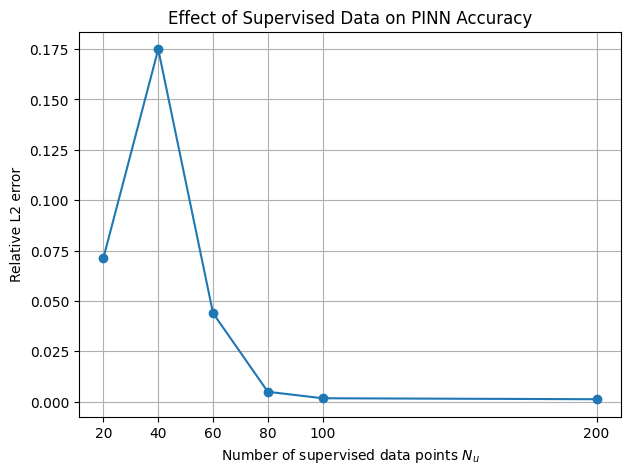

Saved figure to: /content/drive/MyDrive/pinn-burgers-reproduction/results/experiment_2_training_data/figures/Nu_vs_relative_l2.png


In [27]:
df_plot = df_results.sort_values("N_u")

plt.figure(figsize=(7, 5))

plt.plot(
    df_plot["N_u"],
    df_plot["relative_l2_error"],
    marker="o"
)

plt.xticks(N_u_values)

plt.xlabel("Number of supervised data points $N_u$")
plt.ylabel("Relative L2 error")
plt.title("Effect of Supervised Data on PINN Accuracy")
plt.grid(True)

figure_path = (
    f"{FIGURES_DIR}/Nu_vs_relative_l2.png"
)

plt.savefig(
    figure_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Saved figure to:", figure_path)

# Log-scale error plot

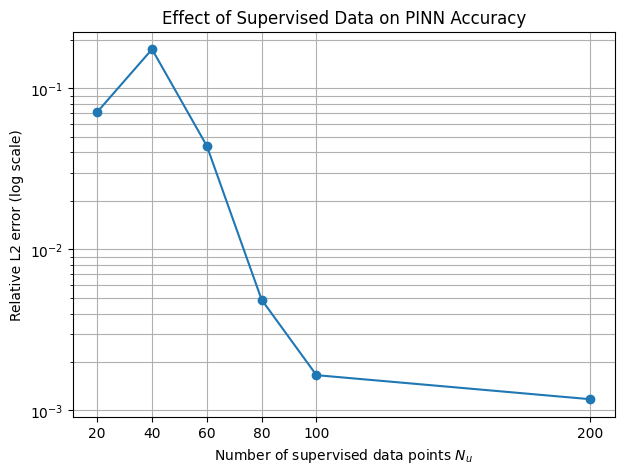

Saved figure to: /content/drive/MyDrive/pinn-burgers-reproduction/results/experiment_2_training_data/figures/Nu_vs_relative_l2_log.png


In [28]:
df_plot = df_results.sort_values("N_u")

plt.figure(figsize=(7, 5))

plt.plot(
    df_plot["N_u"],
    df_plot["relative_l2_error"],
    marker="o"
)

plt.yscale("log")
plt.xticks(N_u_values)

plt.xlabel("Number of supervised data points $N_u$")
plt.ylabel("Relative L2 error (log scale)")
plt.title("Effect of Supervised Data on PINN Accuracy")
plt.grid(True, which="both")

figure_path = (
    f"{FIGURES_DIR}/Nu_vs_relative_l2_log.png"
)

plt.savefig(
    figure_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Saved figure to:", figure_path)

# Training-time plot

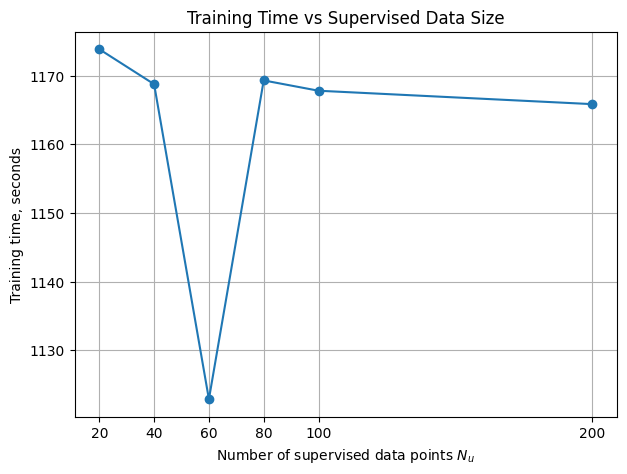

Saved figure to: /content/drive/MyDrive/pinn-burgers-reproduction/results/experiment_2_training_data/figures/Nu_vs_training_time.png


In [29]:
df_plot = df_results.sort_values("N_u")

plt.figure(figsize=(7, 5))

plt.plot(
    df_plot["N_u"],
    df_plot["training_time_seconds"],
    marker="o"
)

plt.xticks(N_u_values)

plt.xlabel("Number of supervised data points $N_u$")
plt.ylabel("Training time, seconds")
plt.title("Training Time vs Supervised Data Size")
plt.grid(True)

figure_path = (
    f"{FIGURES_DIR}/Nu_vs_training_time.png"
)

plt.savefig(
    figure_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Saved figure to:", figure_path)

## data-loss plot

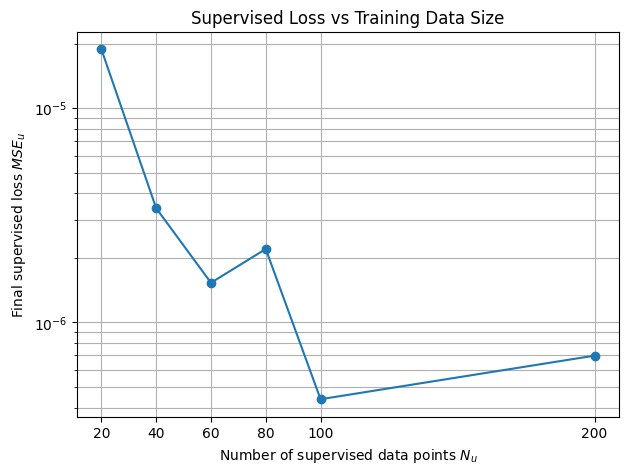

Saved figure to: /content/drive/MyDrive/pinn-burgers-reproduction/results/experiment_2_training_data/figures/Nu_vs_final_mse_u.png


In [30]:
df_plot = df_results.sort_values("N_u")

plt.figure(figsize=(7, 5))

plt.plot(
    df_plot["N_u"],
    df_plot["final_mse_u"],
    marker="o"
)

plt.yscale("log")
plt.xticks(N_u_values)

plt.xlabel("Number of supervised data points $N_u$")
plt.ylabel("Final supervised loss $MSE_u$")
plt.title("Supervised Loss vs Training Data Size")
plt.grid(True, which="both")

figure_path = (
    f"{FIGURES_DIR}/Nu_vs_final_mse_u.png"
)

plt.savefig(
    figure_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Saved figure to:", figure_path)

# Conclusion

This experiment studied how the number of supervised initial and boundary data points affects PINN accuracy.

The number of collocation points was fixed at `N_f = 10000`, and the network architecture was fixed at 8 hidden layers with 20 neurons per layer. Only the supervised data size `N_u` was changed.

The results show a strong overall improvement as more supervised data is provided. The relative L2 error decreases from `0.0713` at `N_u = 20` to `0.00118` at `N_u = 200`. The model with 200 supervised points is therefore about 61 times more accurate than the model with 20 points.

The trend is not perfectly monotonic. In particular, `N_u = 40` performs worse than `N_u = 20`. This can occur because PINN optimization is non-convex and sensitive to the selected training points and optimizer convergence. A single run is therefore not expected to produce a perfectly smooth relationship.

A large improvement occurs between `N_u = 60` and `N_u = 100`. Increasing the data size from 100 to 200 still improves accuracy, but the improvement is smaller, suggesting diminishing returns.

Training time remains almost constant across the experiments because the dominant computational cost comes from evaluating the PDE residual at the fixed 10,000 collocation points.

Overall, the experiment shows that the PDE residual allows the PINN to learn from relatively little supervised data, but sufficient initial and boundary information is still necessary for high accuracy.